In [ ]:
!pip install statsmodels


In [ ]:
import pandas as pd

df = pd.read_csv("/content/summer_peaks.csv")


df['day'] = pd.to_datetime(df['day'])


df.set_index("day", inplace=True)

df.head()




,wd,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,energy,peak_power,peak_duration,peak_intensity,is_peak,activity
day,,,,,,,,,,,,,,,,,
2018-06-01,5,16.80,15.96,15.81,15.48,15.32,18.27,22.62,24.72,25.54,26.43,25235.6,1473.6,0,0.0,False,0.60
2018-06-02,6,14.81,14.35,13.62,13.31,13.53,18.24,21.04,24.39,27.00,27.34,21944.8,1140.8,0,0.0,False,0.01
2018-06-03,7,14.74,14.65,14.28,13.89,13.65,18.47,21.62,24.64,26.16,26.64,21521.6,1097.6,0,0.0,False,0.10
2018-06-04,1,14.75,13.93,13.49,13.13,13.51,19.29,22.03,25.57,27.60,28.62,25397.6,1467.2,0,0.0,False,1.00
2018-06-05,2,16.86,17.44,16.75,15.83,15.37,18.04,21.21,25.59,25.18,26.89,24474.8,1494.4,0,0.0,False,1.00


In [ ]:
# Monthly electricity consumption
monthly_energy = df['energy'].resample("M").sum()

# Monthly average temperature (use mean of T1–T10)
df["avg_temp"] = df[[f"T{i}" for i in range(1,11)]].mean(axis=1)

monthly_temp = df["avg_temp"].resample("M").mean()

# Combine into one dataframe
monthly_df = pd.DataFrame({
    "energy": monthly_energy,
    "temp": monthly_temp
})

monthly_df.head()


/tmp/ipython-input-569514839.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_energy = df['energy'].resample("M").sum()
/tmp/ipython-input-569514839.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df["avg_temp"].resample("M").mean()


,energy,temp
day,,
2018-06-30,712075.2,19.061600
2018-07-31,769597.2,20.935129
2018-08-31,790045.2,22.009548
2018-09-30,663334.4,17.017800
2018-10-31,0.0,NaN


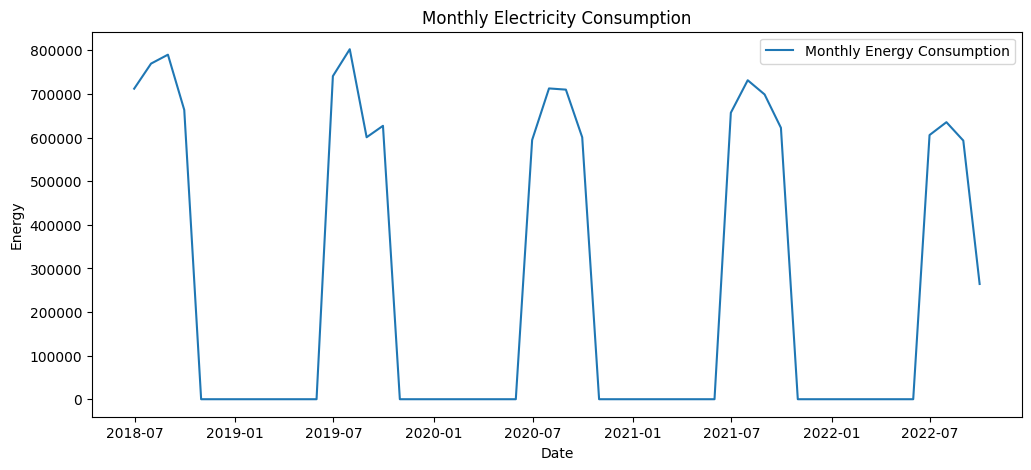

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_df["energy"], label="Monthly Energy Consumption")
plt.title("Monthly Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Energy")
plt.legend()
plt.show()


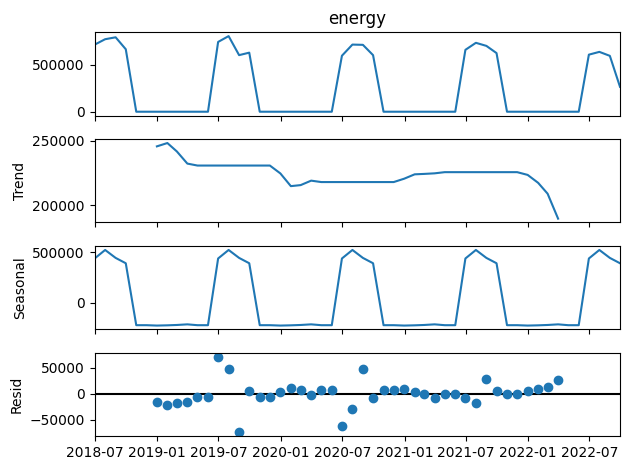

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(monthly_df["energy"], model="additive", period=12)

decomp.plot()
plt.show()


In [ ]:
train = monthly_df.iloc[:-6]
test  = monthly_df.iloc[-6:]

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 46
Test size: 6


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train["energy"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()
print(sarima_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                             energy   No. Observations:                   46
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -403.914
Date:                            Mon, 09 Feb 2026   AIC                            817.829
Time:                                    04:23:58   BIC                            825.311
Sample:                                06-30-2018   HQIC                           820.346
                                     - 03-31-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0654      0.360     -0.182      0.856      -0.770       0.639
ma.L1         -0.6480      0.141   

In [ ]:
sarima_forecast = sarima_fit.forecast(steps=len(test))


In [ ]:
sarimax_model = SARIMAX(
    train["energy"],
    exog=train["temp"].interpolate(method='linear', limit_direction='both'), # Interpolate NaN values in 'temp'
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarimax_fit = sarimax_model.fit()
print(sarimax_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                             energy   No. Observations:                   46
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -397.233
Date:                            Mon, 09 Feb 2026   AIC                            806.466
Time:                                    04:24:37   BIC                            815.445
Sample:                                06-30-2018   HQIC                           809.487
                                     - 03-31-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp        1.269e+04   1948.753      6.513      0.000    8871.992    1.65e+04
ar.L1         -0.1846      0.323   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
sarimax_forecast = sarimax_fit.forecast(
    steps=len(test),
    exog=test["temp"].interpolate(method='linear', limit_direction='both')
)

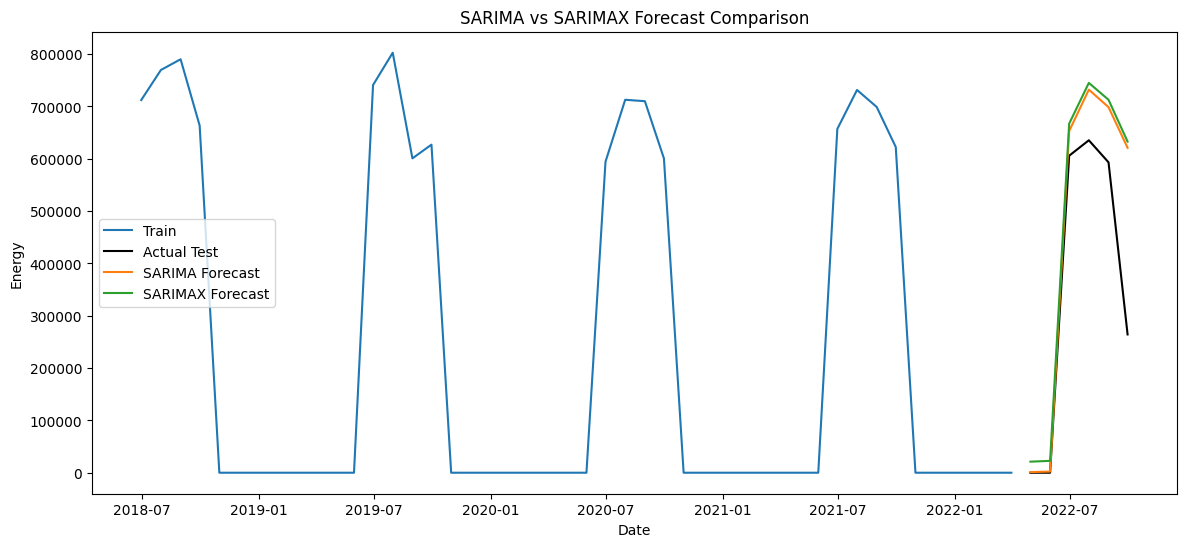

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["energy"], label="Train")
plt.plot(test.index, test["energy"], label="Actual Test", color="black")

plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")
plt.plot(test.index, sarimax_forecast, label="SARIMAX Forecast")

plt.title("SARIMA vs SARIMAX Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Energy")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def metrics(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return mae, rmse, mape

sarima_mae, sarima_rmse, sarima_mape = metrics(test["energy"], sarima_forecast)
sarimax_mae, sarimax_rmse, sarimax_mape = metrics(test["energy"], sarimax_forecast)

print("📌 SARIMA Performance")
print("MAE :", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

print("\n📌 SARIMAX Performance")
print("MAE :", sarimax_mae)
print("RMSE:", sarimax_rmse)
print("MAPE:", sarimax_mape)


📌 SARIMA Performance
MAE : 101558.52586126974
RMSE: 158061.57969123014
MAPE: inf

📌 SARIMAX Performance
MAE : 117117.12273863728
RMSE: 166735.71758197944
MAPE: inf


In [ ]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "SARIMAX"],
    "MAE": [sarima_mae, sarimax_mae],
    "RMSE": [sarima_rmse, sarimax_rmse],
    "MAPE (%)": [sarima_mape, sarimax_mape]
})

comparison


,Model,MAE,RMSE,MAPE (%)
0,SARIMA,101558.525861,158061.579691,inf
1,SARIMAX,117117.122739,166735.717582,inf


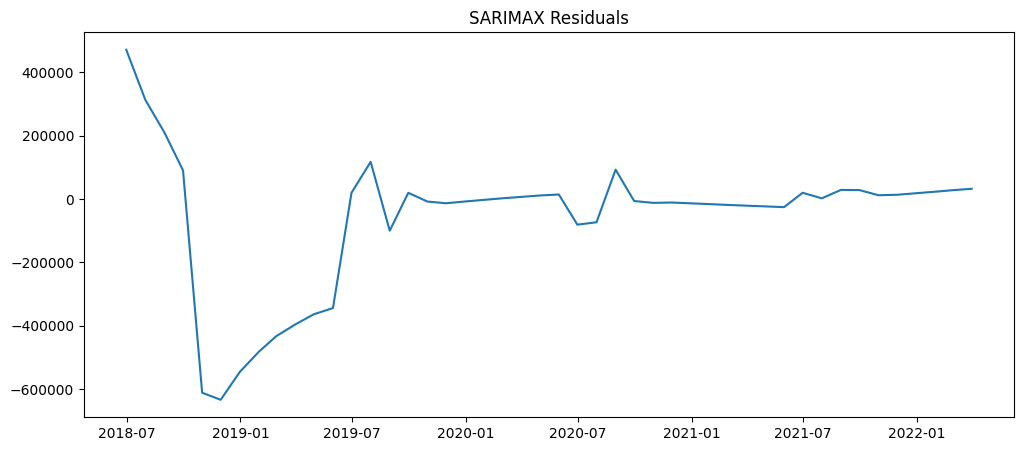

In [ ]:
residuals = sarimax_fit.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("SARIMAX Residuals")
plt.show()


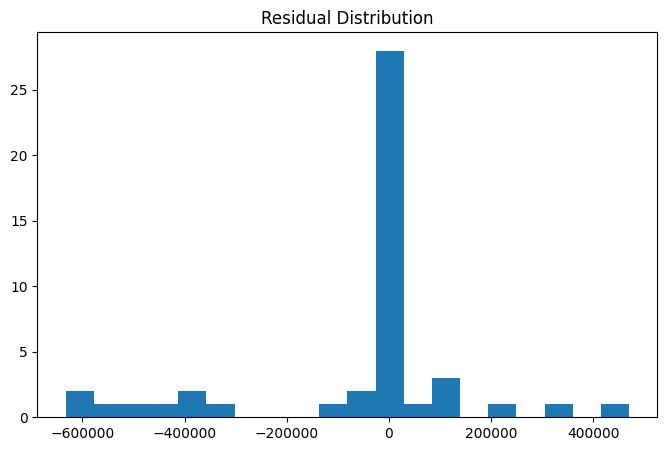

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution")
plt.show()


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)


      lb_stat     lb_pvalue
10  53.860121  5.152188e-08


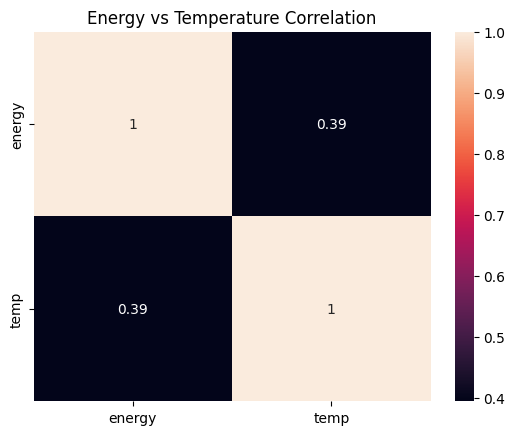

In [ ]:
import seaborn as sns

sns.heatmap(monthly_df.corr(), annot=True)
plt.title("Energy vs Temperature Correlation")
plt.show()
